<a href="https://colab.research.google.com/github/Cal-Zayn/Tugas-FSD-Logistic-Regression/blob/main/P05_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kelompok :
- 24523147 (Muhammad Zayyan Achnaf)
- 24523149 (Orian Edsel Devanendra)

Dataset ini adalah **Penggunaan Layanan Keuangan** (Use of Financial Services) dari **seluruh dunia** dengan perhitungan secara runtun waktu.

Dirilis oleh lembaga seperti International Monetary Fund (IMF), yang berfokus untuk mengukur tingkat inklusi keuangan di berbagai negara.


**Pertama melihat dataset dan Informasinya**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

file_path = '/content/FAS_03-20-2017 13-17-21-06_timeSeries.csv'
df = pd.read_csv(file_path)

print("Info Dataset:")
display(df.info())
print("\n5 Baris Pertama:")
display(df.head())

# Catatan: Karena ini data deret waktu, target klasifikasinya ditentukan dari kolom label tertentu.

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21096 entries, 0 to 21095
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   index           21096 non-null  int64  
 1   Country Name    21096 non-null  object 
 2   Country Code    21096 non-null  int64  
 3   Indicator Name  21096 non-null  object 
 4   Indicator Code  21096 non-null  object 
 5   Attribute       21096 non-null  object 
 6   2004            6155 non-null   float64
 7   2005            6587 non-null   float64
 8   2006            6884 non-null   float64
 9   2007            7370 non-null   float64
 10  2008            7850 non-null   float64
 11  2009            8255 non-null   float64
 12  2010            8661 non-null   float64
 13  2011            9091 non-null   float64
 14  2012            9444 non-null   float64
 15  2013            9668 non-null   float64
 16  2014            9560 non-null   float64
 17  2015            9

None


5 Baris Pertama:


,index,Country Name,Country Code,Indicator Name,Indicator Code,Attribute,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,Unnamed: 18
0,0,Botswana,616,"Use of Financial Services, Liabilities: Outsta...",FCLODDH_XDC,Value,359774000.0,377955000.0,416346000.0,5.329350e+08,8.126760e+08,7.198000e+08,7.558000e+08,6.478000e+08,8.651180e+08,1.212298e+09,8.777000e+08,1260143000,NaN,NaN
1,1,Brunei Darussalam,516,"Use of Financial Services, Liabilities: Outsta...",FCLODDH_XDC,Value,NaN,NaN,NaN,NaN,NaN,NaN,9.714985e+08,1.003379e+09,1.027375e+09,1.067159e+09,1.061700e+09,1101122000,NaN,NaN
2,2,"Armenia, Republic of",911,"Use of Financial Services, Liabilities: Outsta...",FCLODDH_XDC,Value,257452000.0,287521000.0,475531000.0,1.112026e+09,1.575405e+09,1.878545e+09,2.648633e+09,3.504000e+09,7.599599e+09,9.575089e+09,2.115274e+10,20369782130,NaN,NaN
3,3,Burundi,618,"Geographical Outreach, Number of Branches, Exc...",FCBMFN_NUM,Value,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,NaN,NaN
4,4,Cyprus,423,"Geographical Outreach, Number of Branches, Exc...",FCBMFN_NUM,Status,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2. Preprocessing Data


In [26]:
from sklearn.preprocessing import StandardScaler


if '2015' in df.columns:
    df['2015'] = pd.to_numeric(df['2015'], errors='coerce')


numeric_df = df.select_dtypes(include=[np.number])

numeric_df = numeric_df.dropna(axis=1, how='all')

target_col = 'Country Code'
df['target'] = (numeric_df[target_col] > numeric_df[target_col].median()).astype(int)

numeric_df = numeric_df.fillna(numeric_df.median())

X = numeric_df
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Preprocessing selesai. Fitur yang digunakan:", list(X.columns))

Preprocessing selesai. Fitur yang digunakan: ['index', 'Country Code', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']


### 3. Pembagian Data Training dan Testing

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Data siap. Training: {len(X_train)} baris, Testing: {len(X_test)} baris.")

Data siap. Training: 16876 baris, Testing: 4220 baris.


### 4. Membangun Model Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Akurasi Model:", accuracy_score(y_test, y_pred))
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

Akurasi Model: 0.985781990521327

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2141
           1       1.00      0.97      0.99      2079

    accuracy                           0.99      4220
   macro avg       0.99      0.99      0.99      4220
weighted avg       0.99      0.99      0.99      4220



### 5.Menampilkan Classification Report dan visualisasi dari Confusion Matrix.

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2141
           1       1.00      0.97      0.99      2079

    accuracy                           0.99      4220
   macro avg       0.99      0.99      0.99      4220
weighted avg       0.99      0.99      0.99      4220



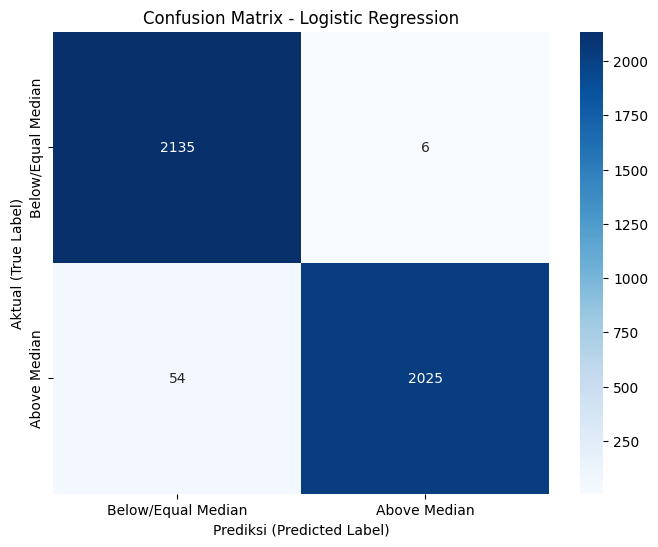

In [32]:


print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Below/Equal Median', 'Above Median'],
            yticklabels=['Below/Equal Median', 'Above Median'])

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Prediksi (Predicted Label)')
plt.ylabel('Aktual (True Label)')
plt.show()

### 6. Perbandingan Hasil Prediksi dan Label Aktual


In [33]:
comparison_df = pd.DataFrame({
    'Label Aktual (y_test)': y_test.values,
    'Hasil Prediksi (y_pred)': y_pred
})

print(f"Menampilkan seluruh {len(comparison_df)} baris hasil prediksi:")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(comparison_df)

Menampilkan seluruh 4220 baris hasil prediksi:


,Label Aktual (y_test),Hasil Prediksi (y_pred)
0,0,0
1,1,1
2,1,1
3,1,1
4,0,0
5,0,0
6,0,0
7,1,1
8,1,1
9,0,0


###Analisis


1. Kinerja Model ini berdasarkan Classification Report karna akurasi yang dihasilkan sangat tinggi bisa mencapai kisaran (99%), sangat presisi dan tentunya juga teliti (dari kategori bawah sampai atas).


2. Makna Dari TP, TN, FP, FN

- True Positive (TP) : Untuk menebak "Kategori Atas" dan kenyataannya memang "Kategori Atas" (Tebakan Benar)

- True Negative (TN) : Untuk menebak "Kategori Bawah" dan kenyataannya memang "Kategori Bawah" (Tebakan juga benar)

- False Positive (FP): Untuk menebak 'Kategori Atas', padahal aslinya itu adalah 'Kategori Bawah'. (Salah tebakan, yang mengira lebih tinggi dari aslinya).

- False Negative (FN): Model menebak 'Kategori Bawah', padahal aslinya itu adalah 'Kategori Atas'. (Salah tebakan, yang mengira lebih rendah dari aslinya).

- Dalam tabel yang kami pilih, angka FP dan FN sangat kecil, yang artinya modelnya jarang salah untuk mengelompokkan negara.

3. Berdasarkan seluruh proses yang telah dilakukan,

- Model ini bekerja dengan sangat baik. Dengan akurasi mencapai 99%, model terbukti mampu mempelajari pola perbedaan antara negara dengan 'Country Code' tinggi dan rendah hampir tanpa kesalahan.

- Keseimbangan yang Baik: Model memiliki nilai Precision dan Recall yang seimbang yang artinya, model sangat mampu untuk mengenali negara di kategori 'Atas' maupun kategori 'Bawah'.

- Keandalan: Karena jumlah kesalahan (False Positive dan False Negative) sangat minim, model ini sangat bisa diandalkan untuk tugas klasifikasi pada data sejenis.

- Kesimpulannya : Dengan Logistic Regression, yang sangat cocok dan efisien untuk dataset ini membuktikan bahwa preprocessing yang kami lakukan diawal hingga akhir proses telah berhasil membuat model bekerja secara optimal.